# Introduction

Healthcare inequity is a global challenge.

Addressing this challenge has an extensive positive impact on women’s health, which is key for societies and economies to thrive.

This datathon was designed to help discover whether disparate treatments exist and to understand the drivers of those biases, such as demographic and societal factors.


In [ ]:
# Import Libraries

import numpy as np # linear algebra
import pandas as pd # for data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # for data visualization
import matplotlib.pyplot as plt # for data visulaization
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
!pip install catboost
import catboost
import xgboost
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.4 MB/s eta 0:00:00


In [ ]:
import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

# Load datasets

The dataset for this challenge contained health related information of patients who were diagnosed with metastatic triple negative breast cancers in the US.

The data set was also enriched with the US Zip Codes Database which were built from the ground up using authoritative sources including the U.S. Postal Service™, U.S. Census Bureau, National Weather Service, American Community Survey, and the IRS, to obtain additional social economic information based on the locations of the patients.


The dataset was then further enriched, also using zip code level, with toxicology data from NASA/Columbia University, to explore the relations between health outcomes and toxic air conditions.


In [ ]:
# Load Competiton Datasets and drop breast_cancer_diagnosis_code
df = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/training.csv").drop("breast_cancer_diagnosis_code",axis=1)
tdf = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/test.csv").drop("breast_cancer_diagnosis_code",axis=1)
ss = pd.read_csv("/content/drive/MyDrive/Data mining/widsdatathon2024-challenge1/sample_submission.csv")

In [ ]:
df

,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_desc,metastatic_cancer_diagnosis_code,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,Malignant neoplasm of unsp site of unspecified...,C7989,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,Malig neoplm of upper-outer quadrant of right ...,C773,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,Malignant neoplasm of central portion of left ...,C773,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,Malig neoplasm of upper-inner quadrant of left...,C773,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,"Malignant neoplasm of breast (female), unspeci...",C773,...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12901,674178,White,NaN,OH,436,50,F,32.11,Malig neoplm of upper-outer quadrant of right ...,C773,...,17.400000,23.600000,0.864706,19.841176,6.300000,6.247059,38.753055,8.068682,21.140731,1
12902,452909,NaN,COMMERCIAL,CA,945,50,F,NaN,Malignant neoplasm of unspecified site of left...,C773,...,11.243210,7.837037,5.411250,34.700000,3.845679,5.671605,36.469947,6.265266,10.728732,1
12903,357486,NaN,COMMERCIAL,CA,926,61,F,29.24,Malignant neoplasm of unspecified site of left...,C7931,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,1
12904,935417,NaN,NaN,NY,112,37,F,31.00,"Malignant neoplasm of breast (female), unspeci...",C773,...,10.194737,18.642105,14.173684,42.502632,6.392105,1.755263,37.722740,7.879795,27.496367,0


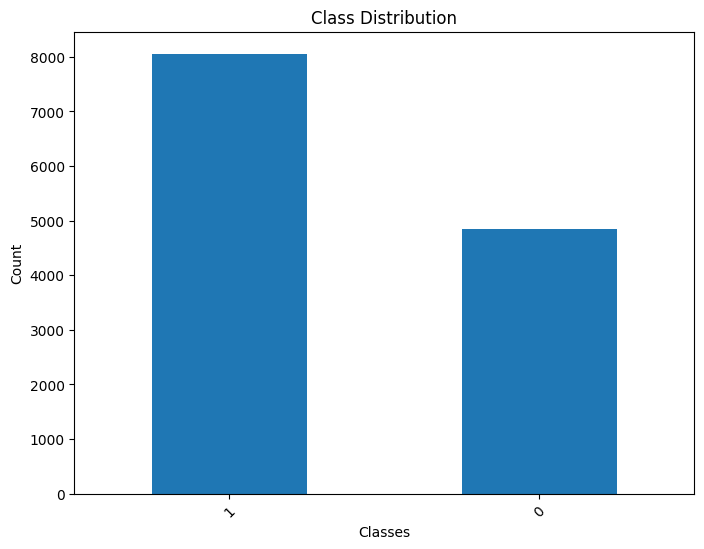

In [ ]:
target = "DiagPeriodL90D"

# Count the occurrences of each class
class_counts = df[target].value_counts()

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

- # Data Cleaning 우리 아이디어

### metastatic_code4 생성

In [ ]:
# meta 칼럼에서 5자리 값을 4자리로 변환
df['meta_code4'] = df['metastatic_cancer_diagnosis_code'].astype(str).apply(lambda x: x[:4] if len(x) >= 5 else x)

# 결과 확인
print(df['meta_code4'].nunique())
print(df['meta_code4'].value_counts())

In [ ]:
# 드랍하기

['metastatic_cancer_diagnosis_code'].

### 유방암 코드 매핑

In [ ]:
## ICD9 -> ICD10 매핑
## breast_cancer_diagnosis_desc
## breast_cancer_diagnosis_code

# 1. ICD9 -> ICD10 코드(code) 매핑
icd9_to_icd10 = {
    '1749': 'C50919', '1744': 'C50419',
    '1748': 'C50819', '1742': 'C50219',
    '1741': 'C50119', '1745': 'C50519',
    '1743': 'C50319', '1746': 'C50619',
    '19881': 'C7981', '1759': 'C50929'
}

# 2. ICD-10 ➝ 진단명(desc) 매핑
icd10_to_desc = {
    "C50919": "Malignant neoplasm of unsp site of unspecified female breast",
    "C50419": "Malig neoplasm of upper-outer quadrant of unsp female breast",
    "C50819": "Malignant neoplasm of ovrlp sites of unsp female breast",
    "C50219": "Malig neoplasm of upper-inner quadrant of unsp female breast",
    "C50119": "Malignant neoplasm of central portion of unsp female breast",
    "C50519": "Malig neoplasm of lower-outer quadrant of unsp female breast",
    "C50319": "Malig neoplasm of lower-inner quadrant of unsp female breast",
    "C50619": "Malignant neoplasm of axillary tail of unsp female breast",
    "C50929": "Malignant neoplasm of unsp site of unspecified male breast",
    "C7981": "Secondary malignant neoplasm of breast"
}


# 1-(1). ICD9 -> ICD10 코드(code) 매핑 적용
df['breast_cancer_diagnosis_code_mapped'] = df['breast_cancer_diagnosis_code'].astype(str).replace(icd9_to_icd10)

# 2-(2). ICD-10 ➝ 진단명(desc) 매핑 적용
df['breast_cancer_diagnosis_desc_mapped'] = df['breast_cancer_diagnosis_code_mapped'].map(icd10_to_desc).fillna(df['breast_cancer_diagnosis_desc'])

### tumor_site 생성

In [ ]:
# desc를 소문자로 변환하여 새로운 컬럼 생성
df['desc_lower'] = df['breast_cancer_diagnosis_desc_mapped'].str.lower()

# 위치 기반 파생 변수 생성
df['tumor_site'] = np.select(
    [
        df['desc_lower'].str.contains('inner'),
        df['desc_lower'].str.contains('outer') | df['desc_lower'].str.contains('axillary tail'),
        df['desc_lower'].str.contains('central portion') | df['desc_lower'].str.contains('nipple') | df['desc_lower'].str.contains('areola'),
        df['desc_lower'].str.contains('overlapping') | df['desc_lower'].str.contains('ovrlp'),
        df['desc_lower'].str.contains('unspecified') | df['desc_lower'].str.contains('unsp')
    ],
    [
        'Inner',
        'Outer',
        'Central',
        'Overlapping',
        'Unspecified'
    ],
    default='Unspecified'
)
df['tumor_site'].value_counts()

In [ ]:
'유방암 코드 desc 칼럼', '유방암 코드' 삭제?

### 새로운 환경변수 (N02 x PM25 x commute_time)

In [ ]:
# 필요한 컬럼 추출 후 결측치 제거
cols = ['N02', 'PM25', 'commute_time', 'DiagPeriodL90D']
df_clean = df[cols].dropna()

# MinMax 정규화
scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_clean[['N02', 'PM25', 'commute_time']])
df_scaled = pd.DataFrame(scaled_values, columns=['N02_scaled', 'PM25_scaled', 'commute_scaled'])

# 파생변수 생성
df_scaled['NO2xPM25xcommute_scaled'] = (
    df_scaled['N02_scaled'] * df_scaled['PM25_scaled'] * df_scaled['commute_scaled']
)

### 환경변수, region 드랍

In [ ]:
드랍

- # Data Cleaning

Zip code level metadata were dropped except product of N02,PM25 & Ozone

Data set contained missing values which we left unhandled


In [ ]:
#  Find Product of Pollutants
df["N02xOzonexPM25"]=df["N02"]*df["Ozone"]*df["PM25"]
tdf["N02xOzonexPM25"]=tdf["N02"]*tdf["Ozone"]*tdf["PM25"]

In [ ]:
# Drop some features
# List of columns to iterate over
columns_to_iterate = [col for col in df.columns if col not in ["patient_zip3", "N02xOzonexPM25"]]

# Iterate over each column
for col in columns_to_iterate:
    # Your code to operate on each column goes here
    df["check"]=df.groupby(["patient_zip3","N02xOzonexPM25"])[col].transform("nunique")
    if df["check"].max()==1:
        print("dropped ",col)
        df=df.drop(col,axis=1)
        tdf=tdf.drop(col,axis=1)
df=df.drop("check",axis=1)

dropped  patient_gender
dropped  metastatic_first_novel_treatment
dropped  metastatic_first_novel_treatment_type
dropped  population
dropped  density
dropped  age_median
dropped  age_under_10
dropped  age_10_to_19
dropped  age_20s
dropped  age_30s
dropped  age_40s
dropped  age_50s
dropped  age_60s
dropped  age_70s
dropped  age_over_80
dropped  male
dropped  female
dropped  married
dropped  divorced
dropped  never_married
dropped  widowed
dropped  family_size
dropped  family_dual_income
dropped  income_household_median
dropped  income_household_under_5
dropped  income_household_5_to_10
dropped  income_household_10_to_15
dropped  income_household_15_to_20
dropped  income_household_20_to_25
dropped  income_household_25_to_35
dropped  income_household_35_to_50
dropped  income_household_50_to_75
dropped  income_household_75_to_100
dropped  income_household_100_to_150
dropped  income_household_150_over
dropped  income_household_six_figure
dropped  income_individual_median
dropped  home_owner

In [ ]:
# define target variable and categorical features
cat_cols = list(tdf.columns[tdf.dtypes=="object"])
cols = [col for col in tdf.columns if col not in ["patient_id"]]
tdf[target] = np.nan

In [ ]:
# concatenate train and test set
df = pd.concat([df,tdf[df.columns]],axis=0)

- # Feature Engineering

We then combined various pollutants into a single feature.

Our goal was to capture the overall environmental impact in a more digestible form for our models. Additionally, we introduced flags for critical variables:

A flag for metastatic_cancer_diagnosis_code with a length of 4 to identify specific diagnosis codes of interest.

A flag for breast_cancer_diagnosis_desc containing the term "female".

We applied one-hot encoding to a carefully selected set of features, including payer_type, patient_race, and breast_cancer_diagnosis_desc, among others

In [ ]:
df["clust"]=(df.metastatic_cancer_diagnosis_code.str.len()==4).astype("int")
df["is_female"] = df.breast_cancer_diagnosis_desc.str.contains("female").astype("int")
df["is_female"].value_counts()

,count
is_female,
1,18665
0,33


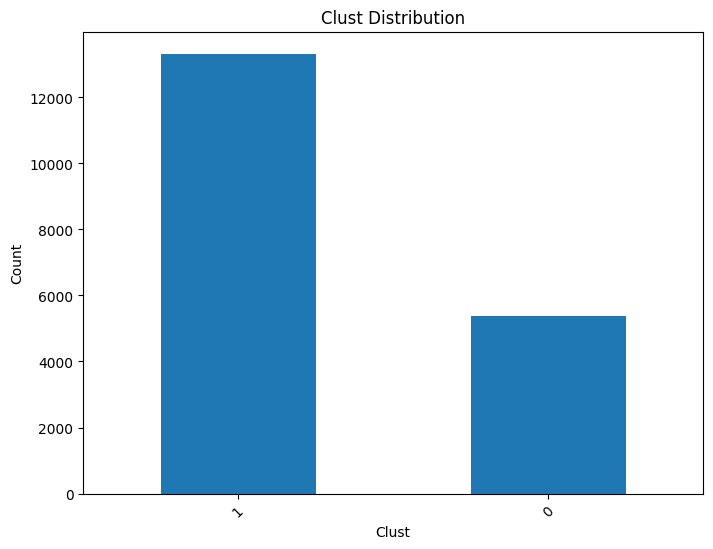

In [ ]:
# Count the occurrences of each class
clust_counts = df["clust"].value_counts()

# Plot the clust distribution
plt.figure(figsize=(8, 6))
clust_counts.plot(kind='bar')
plt.title('Clust Distribution')
plt.xlabel('Clust')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [ ]:
# do one-hot encoding for some features
age_cols = list(df.filter(regex="age").columns)
cols = list(set(cols)-set(age_cols))
income_cols = list(df.filter(regex="income").columns)
cols = list(set(cols)-set(income_cols))
cols = list(set(cols)-{"breast_cancer_diagnosis_code","N02xOzonexPM25","bmi"})
df=pd.get_dummies(df,columns=cols,dtype="int",drop_first=True)
cols

['breast_cancer_diagnosis_desc',
 'Division',
 'patient_state',
 'patient_zip3',
 'payer_type',
 'metastatic_cancer_diagnosis_code',
 'Region',
 'patient_race']

In [ ]:
# do label encoding for categorical columns
le=LabelEncoder()
for col in cat_cols:
    try:
        df[col]=le.fit_transform(df[col]).astype("int")
        print(col)
    except:
        continue

In [ ]:
tdf=df[df[target].isna()]
df=df[df[target].notna()]
len(df),len(tdf)

(12906, 5792)

- # Modelling

Our model architecture consisted of base models and a meta-model:

Base Models: We utilized two CatBoost models and one XGBoost model.

These models were chosen for their robust handling of categorical features and their ability to handle the missing data in our dataset.


Meta-Model: A Logistic Regression model served as our meta-model.

In [ ]:
modela = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
modelb = CatBoostClassifier(iterations=500, silent=True, learning_rate=0.05, depth=10, eval_metric='AUC', random_seed=42)
model2a = XGBClassifier(
    learning_rate=0.1,
    max_depth=6,
    n_estimators=100,
    subsample=0.9
)

In [ ]:
# finalize features for training
drop_cols=["patient_id",target,"patient_zip3","patient_state"]
cols=list(set(df.columns)-set(drop_cols))

In [ ]:
# Define the number of folds
num_folds = 10
from sklearn.model_selection import StratifiedKFold
kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

In [ ]:
# use stacking method, define meta model
from sklearn.linear_model import LogisticRegression
meta_model = LogisticRegression()
meta_features=['pred1b','pred2','pred1']

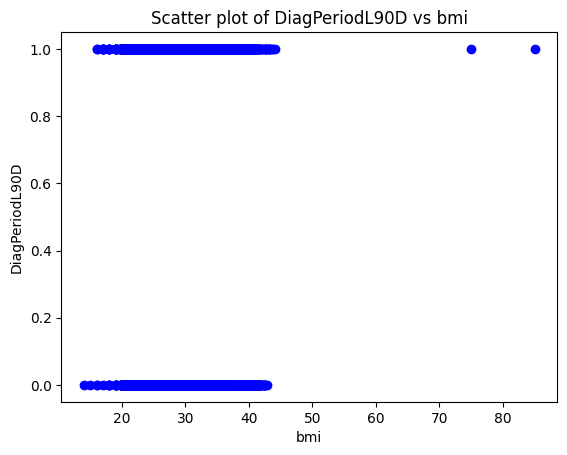

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Plotting
plt.scatter(df['bmi'], df[target], color='blue')
plt.xlabel('bmi')
plt.ylabel(target)
plt.title(f'Scatter plot of {target} vs bmi')
plt.savefig('bmi.png')
plt.show()

In [ ]:
# Initialize empty dataframe to store predictions from all folds
predictions_from_folds=pd.DataFrame()
# Iterate over folds
for fold, (train_index, val_index) in enumerate(kf.split(df, df[target])):
    dfx, efx = df.iloc[train_index], df.iloc[val_index]
    # train and make predictions on train set
    efx["pred1"] = modela.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred2"] = modelb.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    efx["pred1b"] = model2a.fit(dfx[cols].values, dfx[target]).predict_proba(efx[cols].values)[:,1]
    # make predictions on test set
    tdf["pred1"] = modela.predict_proba(tdf[cols].values)[:,1]
    tdf["pred2"] = modelb.predict_proba(tdf[cols].values)[:,1]
    tdf["pred1b"] = model2a.predict_proba(tdf[cols].values)[:,1]
    # train meta-models and make final predictions
    tdf["pred"] = meta_model.fit(efx[meta_features], efx[target]).predict_proba(tdf[meta_features])[:, 1]
    predictions_from_folds=pd.concat([predictions_from_folds,tdf],axis=0)

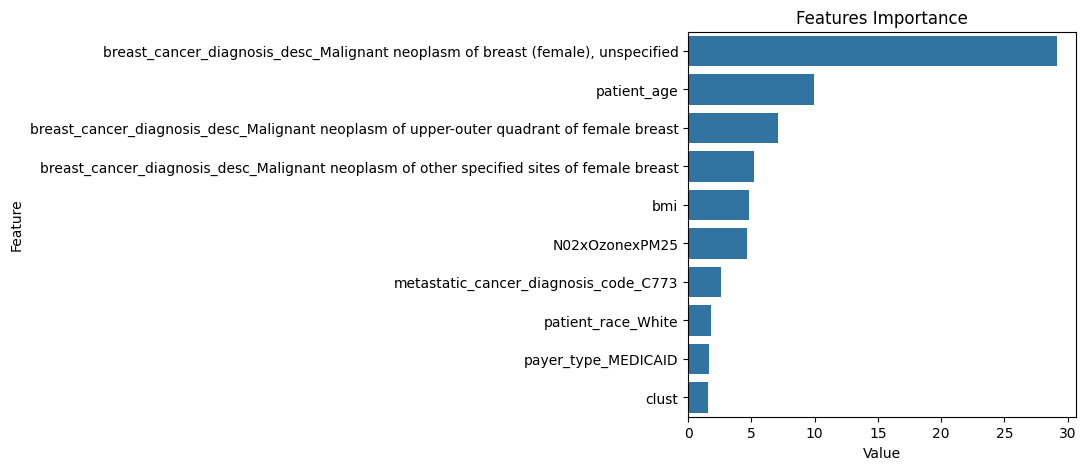

In [ ]:
# feature importance

feature_imp = pd.DataFrame(sorted(zip(modela.feature_importances_,cols)), columns=['Value','Feature'])
feature_imp=feature_imp.sort_values("Value",ascending=False)
feature_imp=feature_imp.head(10)
feature_imp["Feature"]=feature_imp["Feature"]
plt.figure(figsize=(5, 5))
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False))
plt.title('Features Importance')
plt.tight_layout()
plt.savefig('cb_importances.png')
plt.show()

- # Submission

In [ ]:
# blend predictions from all folds
final_predictions=predictions_from_folds.groupby("patient_id").mean().reset_index()
final_predictions[target]=final_predictions["pred"].values
final_predictions[ss.columns].to_csv("final_predictions.csv",index=None)